The dataset contains 5,000 users randomly assigned to either **Group A (Control)** or **Group B (Treatment)**.- page views : talk about number of pages user visit
- Time Spent : talk about how much time user spent in our website
- Conversion : talk about did the user did any purchase or not
- Device : talk of what system is used
- Location : what is the location of the user
- Group : A(control group) = when website background is white, B(Treatement group) = when website background is dark

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ab_testing.csv')
df.head()

,User ID,Group,Page Views,Time Spent,Conversion,Device,Location
0,14292,B,3,424,No,Mobile,Northern Ireland
1,11682,A,9,342,No,Mobile,Scotland
2,19825,A,2,396,No,Desktop,Northern Ireland
3,16080,B,4,318,No,Desktop,Wales
4,18851,A,1,338,Yes,Desktop,Scotland


In [3]:
df.shape

(5000, 7)

In [4]:
df.isnull().sum()

User ID       0
Group         0
Page Views    0
Time Spent    0
Conversion    0
Device        0
Location      0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   User ID     5000 non-null   int64
 1   Group       5000 non-null   str  
 2   Page Views  5000 non-null   int64
 3   Time Spent  5000 non-null   int64
 4   Conversion  5000 non-null   str  
 5   Device      5000 non-null   str  
 6   Location    5000 non-null   str  
dtypes: int64(3), str(4)
memory usage: 273.6 KB


In [6]:
df.dtypes

User ID       int64
Group           str
Page Views    int64
Time Spent    int64
Conversion      str
Device          str
Location        str
dtype: object

In [7]:
df.describe()

,User ID,Page Views,Time Spent
count,5000.000000,5000.000000,5000.000000
mean,14925.159000,7.537600,242.512600
std,2869.153773,4.022465,118.254153
min,10001.000000,1.000000,40.000000
25%,12456.250000,4.000000,137.000000
50%,14858.500000,8.000000,243.000000
75%,17379.750000,11.000000,346.000000
max,19995.000000,14.000000,449.000000


In [8]:
df.describe(include = ["object", "string"])

,Group,Conversion,Device,Location
count,5000,5000,5000,5000
unique,2,2,2,4
top,A,No,Desktop,Scotland
freq,2519,4515,2538,1281


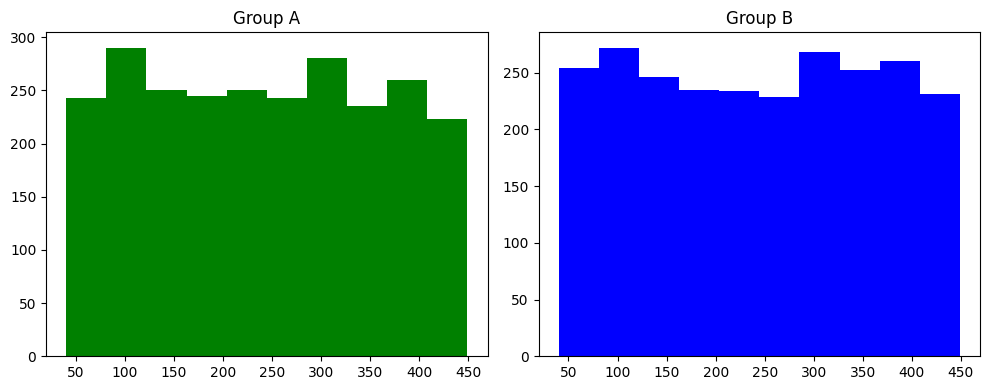

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].hist(df[df['Group'] == 'A']['Time Spent'], color='green')
ax[0].set_title('Group A')

ax[1].hist(df[df['Group'] == 'B']['Time Spent'], color='blue')
ax[1].set_title('Group B')

plt.tight_layout()
plt.show()

In [22]:
Converse = df[df['Conversion'] == 'Yes']

sale = Converse.groupby('Group')['Time Spent'].sum()
sale

Group
A    33373
B    84613
Name: Time Spent, dtype: int64

Now the plot will be showing the sales happen for A and B group

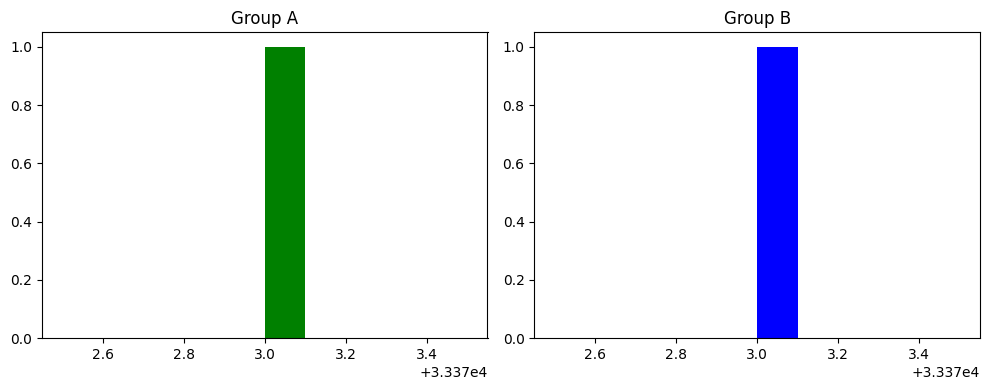

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].hist(sale.values[0], color='green', label = sale.index[0])
ax[0].set_title('Group A')

ax[1].hist(sale.values[0], color='blue', label = sale.index[0])
ax[1].set_title('Group B')

plt.tight_layout()
plt.show()